In [19]:
import pandas as pd
import numpy as np

In [20]:
data_dic = pd.read_csv("YRBS_2023_Data_Dictionary_Ordered.csv")

In [21]:
data_dic.head()

,Variable,Question_Description,Value,Value_Meaning
0,Q1,How old are you,1.0,12 years old or younger
1,Q1,How old are you,2.0,13 years old
2,Q1,How old are you,3.0,14 years old
3,Q1,How old are you,4.0,15 years old
4,Q1,How old are you,5.0,16 years old


In [22]:
raw_data = pd.read_csv('XXH2023_YRBS_Data.csv')
raw_data.head(5)

/tmp/ipykernel_3887/4010718000.py:1: DtypeWarning: Columns (91,92,93,94,95,96,97,103,104,105,106,248) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv('XXH2023_YRBS_Data.csv')


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,QNILLICT,QNOBESE,QNOWT,WEIGHT,STRATUM,PSU,BMIPCT,RACEETH,Q6ORIG,Q7ORIG
0,14 years old,Female,9th grade,NaN,C,1.65,81.65,Most of the time,4 or 5 times,Did not drive,...,NaN,1.0,2.0,0.8614,103,16294,97.08,NaN,505,180
1,15 years old,Male,9th grade,No,E,NaN,NaN,Always,0 times,Did not drive,...,2.0,NaN,NaN,0.8920,103,16294,NaN,White,N N,233
2,16 years old,Male,11th grade,No,E,1.68,74.84,Always,2 or 3 times,Did not drive when drinking,...,1.0,2.0,1.0,0.5081,103,16294,92.26,White,506,165
3,17 years old,Female,10th grade,No,E,NaN,NaN,Most of the time,0 times,Did not drive when drinking,...,1.0,NaN,NaN,1.1759,103,16294,NaN,White,N N,105
4,14 years old,Male,9th grade,No,E,1.85,56.70,Always,0 times,Did not drive,...,2.0,2.0,2.0,0.8920,103,16294,7.57,White,601,125


In [23]:
raw_data.columns

Index(['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10',
       ...
       'QNILLICT', 'QNOBESE', 'QNOWT', 'WEIGHT', 'STRATUM', 'PSU', 'BMIPCT',
       'RACEETH', 'Q6ORIG', 'Q7ORIG'],
      dtype='object', length=250)

In [24]:
selected_columns = ['Q1', 'Q2', 'Q3', 'Q9', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q20',
                    'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q41', 'Q42', 'Q43', 'Q44', 'Q76',
                    'Q80', 'Q84', 'Q85', 'Q86', 'Q87', 'Q89', 'Q90', 'Q91', 'Q100', 'Q101',
                    'Q102', 'Q103', 'Q104', 'Q105', 'Q106']
data = raw_data[selected_columns]

In [25]:
data.columns = ['age', 'gender', 'education_level', 'ride_drinking_driver',
                'school_safety_concern', 'threatened_at_school', 'fight_count',
                'school_fight_count', 'neighborhood_violence', 'sexual_violence',
                'school_racism', 'school_bullying', 'cyber_bullying', 'feel_hopeless',
                'considered_suicide', 'first_alcohol', 'alcohol_frequency',
                'hardcore_alcohol_frequency', 'drinking_in_a_row', 'exercise',
                'social_media', 'mental_health', 'hours_of_sleep', 'sleep_place',
                'grade', 'parent_emotional_abuse', 'parent_physical_abuse',
                'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness',
                'incarcerated_parent', 'have_friend', 'parent_monitoring',
                'unfair_discipline_school', 'ADHD']

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20103 entries, 0 to 20102
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   age                         20005 non-null  object
 1   gender                      19945 non-null  object
 2   education_level             19910 non-null  object
 3   ride_drinking_driver        19598 non-null  object
 4   school_safety_concern       18982 non-null  object
 5   threatened_at_school        17974 non-null  object
 6   fight_count                 11652 non-null  object
 7   school_fight_count          17460 non-null  object
 8   neighborhood_violence       14577 non-null  object
 9   sexual_violence             15752 non-null  object
 10  school_racism               18286 non-null  object
 11  school_bullying             19902 non-null  object
 12  cyber_bullying              19898 non-null  object
 13  feel_hopeless               19863 non-null  ob

In [27]:
data.isnull().sum()

,0
age,98
gender,158
education_level,193
ride_drinking_driver,505
school_safety_concern,1121
threatened_at_school,2129
fight_count,8451
school_fight_count,2643
neighborhood_violence,5526
sexual_violence,4351


In [28]:
data.head()

,age,gender,education_level,ride_drinking_driver,school_safety_concern,threatened_at_school,fight_count,school_fight_count,neighborhood_violence,sexual_violence,...,parent_emotional_abuse,parent_physical_abuse,parent_abuse_parent,parent_uses_alcohol,parent_mental_illness,incarcerated_parent,have_friend,parent_monitoring,unfair_discipline_school,ADHD
0,14 years old,Female,9th grade,4 or 5 times,2 or 3 days,0 times,0 times,0 times,No,0 times,...,NaN,Never,Never,No,Yes,No,Not sure,Sometimes,No,No
1,15 years old,Male,9th grade,0 times,0 days,0 times,1 time,1 time,No,0 times,...,Rarely,Rarely,Rarely,No,No,No,Agree,Always,No,Yes
2,16 years old,Male,11th grade,2 or 3 times,0 days,0 times,0 times,0 times,No,0 times,...,Sometimes,Rarely,Rarely,No,No,Yes,Agree,Most of the time,No,No
3,17 years old,Female,10th grade,0 times,2 or 3 days,0 times,0 times,0 times,No,0 times,...,Never,Never,Never,No,No,No,Disagree,Always,No,Yes
4,14 years old,Male,9th grade,0 times,0 days,0 times,2 or 3 times,0 times,No,0 times,...,Never,Never,Never,No,No,No,Agree,Always,No,No


In [29]:
for col in data.columns:
    print(col)
    print(data[col].unique().tolist())

age
['14 years old', '15 years old', '16 years old', '17 years old', '18 years old or older', nan, '12 years old or younger', '13 years old']
gender
['Female', 'Male', nan]
education_level
['9th grade', '11th grade', '10th grade', '12th grade', 'Ungraded or other grade', nan]
ride_drinking_driver
['4 or 5 times', '0 times', '2 or 3 times', '6 or more times', '1 time', nan]
school_safety_concern
['2 or 3 days', '0 days', '6 or more days', '1 day', nan, '4 or 5 days']
threatened_at_school
['0 times', '1 time', nan, '6 or 7 times', '2 or 3 times', '12 or more times', '10 or 11 times', '4 or 5 times', '8 or 9 times']
fight_count
['0 times', '1 time', '2 or 3 times', '6 or 7 times', '12 or more times', nan, '4 or 5 times', '10 or 11 times', '8 or 9 times']
school_fight_count
['0 times', '1 time', '2 or 3 times', '12 or more times', nan, '8 or 9 times', '4 or 5 times', '6 or 7 times', '10 or 11 times']
neighborhood_violence
['No', 'Yes', nan]
sexual_violence
['0 times', '2 or 3 times', '4 or

In [30]:
def convert(df):
    data = df.copy()

    data['age'] = pd.to_numeric(data['age'].str.extract('(\d+)')[0])

    times_map = {
        '0 times': 0, '1 time': 1, '2 or 3 times': 2, '4 or 5 times': 4,
        '6 or 7 times': 6, '8 or 9 times': 8, '10 or 11 times': 10,
        '12 or more times': 12
    }

    days_map = {
        '0 days': 0, '1 day': 1, '2 days': 2, '3 to 5 days': 4,
        '6 to 9 days': 7, '10 to 19 days': 14, '20 to 29 days': 24,
        'All 30 days': 30
    }

    yes_no = {'Yes': 1, 'No': 0}

    freq_map = {
        'Never': 0, 'Rarely': 1, 'Sometimes': 2,
        'Most of the time': 3, 'Always': 4
    }

    cols_times = ['ride_drinking_driver', 'threatened_at_school', 'fight_count', 'school_fight_count', 'sexual_violence']
    for col in cols_times:
        data[col] = data[col].map(times_map)

    cols_days = ['school_safety_concern', 'alcohol_frequency', 'hardcore_alcohol_frequency']
    for col in cols_days:
        data[col] = data[col].map(days_map)

    cols_yes_no = ['neighborhood_violence', 'school_bullying', 'cyber_bullying', 'feel_hopeless', 'parent_uses_alcohol',
                   'parent_mental_illness', 'incarcerated_parent', 'unfair_discipline_school', 'ADHD']
    for col in cols_yes_no:
        data[col] = data[col].map(yes_no)

    cols_freq = ['school_racism', 'mental_health', 'parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 'parent_monitoring']
    for col in cols_freq:
        data[col] = data[col].map(freq_map)

    first_alcohol_map = {
        'Never drank alcohol': 0, '8 years old or younger': 8, '9 or 10 years old': 9,
        '11 or 12 years old': 11, '13 or 14 years old': 13, '15 or 16 years old': 15, '17 years old or older': 17
    }
    data['first_alcohol'] = data['first_alcohol'].map(first_alcohol_map)

    drink_in_a_row = {
        'Did not drink in past 30 days': 0, '1 or 2 drinks': 1, '3 drinks': 3, '4 drinks': 4,
        '5 drinks': 5, '6 or 7 drinks': 6, '8 or 9 drinks': 8, '10 or more drinks': 10
    }
    data['drinking_in_a_row'] = data['drinking_in_a_row'].map(drink_in_a_row)

    exercise = {
        '0 days': 0, '1 day': 1, '2 days': 2, '3 days': 3,
        '4 days': 4, '5 days': 5, '6 days': 6, '7 days': 7
    }
    data['exercise'] = data['exercise'].map(exercise)

    social_media = {
        "I do not use social media": 0, "A few times a month": 1, "About once a week": 2, "A few times a week": 3,
        "About once a day": 4, "Several times a day": 5, "About once an hour": 6, "More than once an hour": 7
    }
    data['social_media'] = data['social_media'].map(social_media)

    sleep_hours = {
        '4 or less hours': 4,
        '5 hours': 5,
        '6 hours': 6,
        '7 hours': 7,
        '8 hours': 8,
        '9 hours': 9,
        '10 or more hours': 10
    }
    data['hours_of_sleep'] = data['hours_of_sleep'].map(sleep_hours)

    grades = {
        'Mostly A\'s': 4, 'Mostly B\'s': 3, 'Mostly C\'s': 2, 'Mostly D\'s': 1,
        'Mostly F\'s': 0
    }
    data['grade'] = data['grade'].map(grades)

    feel_close = {
        'Strongly agree': 4, 'Agree': 3, 'Not sure': 2, 'Disagree': 1, 'Strongly disagree': 0
    }
    data['have_friend'] = data['have_friend'].map(feel_close)

    return data

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3887/3653777280.py:4: SyntaxWarning: invalid escape sequence '\d'
  data['age'] = pd.to_numeric(data['age'].str.extract('(\d+)')[0])


In [31]:
def clean(df):
    data = df.copy()
    data = data.dropna(subset=['grade'])

    med = ['age', 'ride_drinking_driver', 'school_safety_concern', 'threatened_at_school', 'fight_count', 'school_fight_count',
           'school_racism', 'first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row',
           'exercise', 'social_media', 'mental_health', 'hours_of_sleep', 'parent_emotional_abuse', 'parent_physical_abuse',
           'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'have_friend',
           'parent_monitoring', 'unfair_discipline_school', 'ADHD']
    for i in med:
        data[i] = data[i].fillna(data[i].median())

    for col in data.select_dtypes(include='number').columns:
        data[col] = data[col].fillna(-1)

    # All other columns
    for i in data.columns[data.isnull().any()].tolist():
        data[i] = data[i].fillna('unknown')

    return data

In [32]:
converted_data = convert(data)
cleaned_data = clean(converted_data)

In [33]:
cleaned_data

,age,gender,education_level,ride_drinking_driver,school_safety_concern,threatened_at_school,fight_count,school_fight_count,neighborhood_violence,sexual_violence,...,parent_emotional_abuse,parent_physical_abuse,parent_abuse_parent,parent_uses_alcohol,parent_mental_illness,incarcerated_parent,have_friend,parent_monitoring,unfair_discipline_school,ADHD
1,15.0,Male,9th grade,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,3.0,4.0,0.0,1.0
2,16.0,Male,11th grade,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,0.0,0.0
3,17.0,Female,10th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0
4,14.0,Male,9th grade,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0
5,16.0,Male,9th grade,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,2.0,3.0,0.0,0.0,0.0,0.0,4.0,4.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20096,15.0,Male,9th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0
20099,15.0,Male,9th grade,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0
20100,15.0,Male,9th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0
20101,16.0,Male,9th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0


In [34]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15694 entries, 1 to 20102
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         15694 non-null  float64
 1   gender                      15694 non-null  object 
 2   education_level             15694 non-null  object 
 3   ride_drinking_driver        15694 non-null  float64
 4   school_safety_concern       15694 non-null  float64
 5   threatened_at_school        15694 non-null  float64
 6   fight_count                 15694 non-null  float64
 7   school_fight_count          15694 non-null  float64
 8   neighborhood_violence       15694 non-null  float64
 9   sexual_violence             15694 non-null  float64
 10  school_racism               15694 non-null  float64
 11  school_bullying             15694 non-null  float64
 12  cyber_bullying              15694 non-null  float64
 13  feel_hopeless               15694 no

In [61]:
alcohol_related_data = cleaned_data[['grade','first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']]
alcohol_related_data.head()

,grade,first_alcohol,alcohol_frequency,hardcore_alcohol_frequency,drinking_in_a_row
1,1.0,0.0,0.0,0.0,0.0
2,2.0,15.0,0.0,0.0,0.0
3,2.0,13.0,0.0,0.0,1.0
4,1.0,13.0,0.0,0.0,1.0
5,0.0,8.0,0.0,0.0,0.0


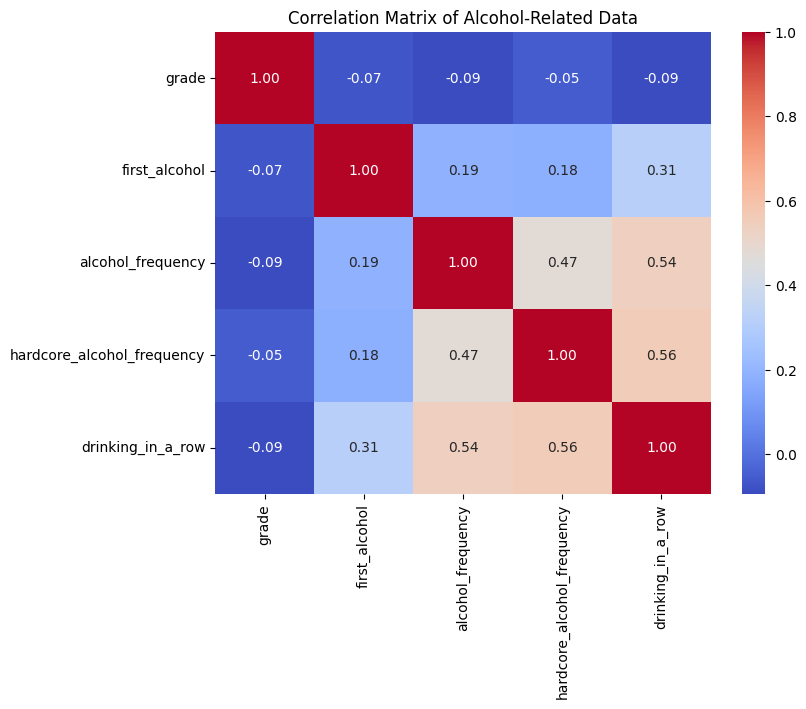

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(alcohol_related_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Alcohol-Related Data')
plt.show()

In [43]:
grade_alcohol_means = alcohol_related_data.groupby('grade').mean()
display(grade_alcohol_means)

,first_alcohol,alcohol_frequency,hardcore_alcohol_frequency,drinking_in_a_row
grade,,,,
0.0,7.102767,2.373518,0.292490,1.328063
1.0,6.578385,1.258907,0.403800,1.090261
2.0,6.384702,0.878890,0.254593,0.722535
3.0,6.090302,0.642324,0.191991,0.630546
4.0,5.409719,0.561731,0.155201,0.510402


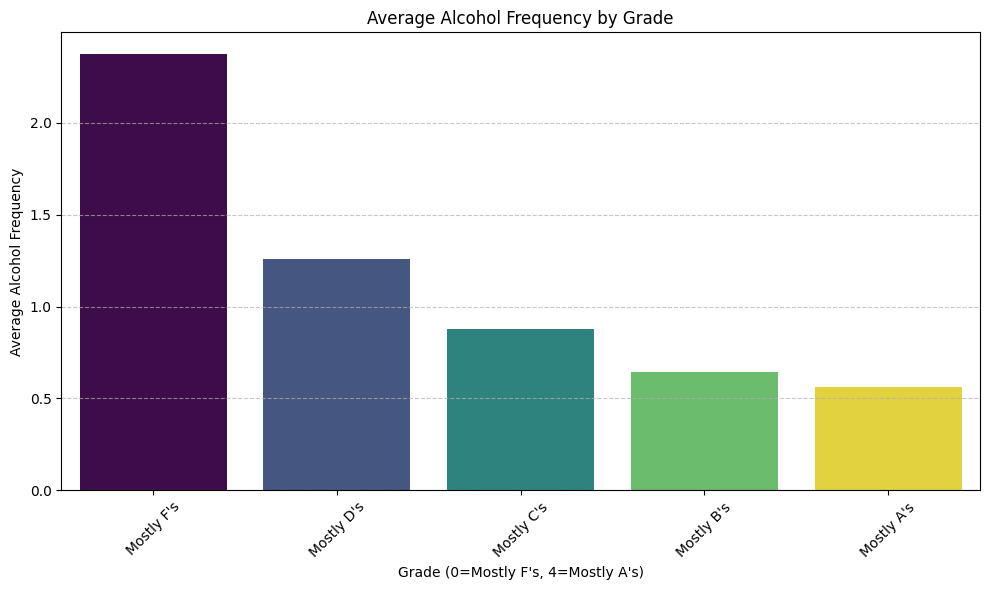

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(x=grade_alcohol_means.index, y='alcohol_frequency', data=grade_alcohol_means, palette='viridis', hue=grade_alcohol_means.index, legend=False)
plt.title('Average Alcohol Frequency by Grade')
plt.xlabel('Grade (0=Mostly F\'s, 4=Mostly A\'s)')
plt.ylabel('Average Alcohol Frequency')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Mostly F\'s', 'Mostly D\'s', 'Mostly C\'s', 'Mostly B\'s', 'Mostly A\'s'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

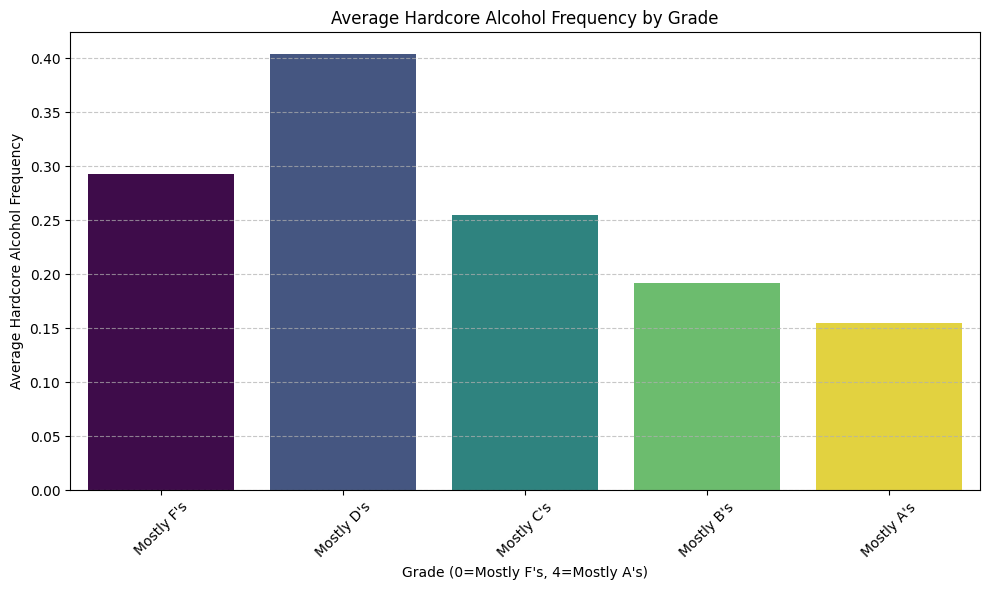

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(x=grade_alcohol_means.index, y='hardcore_alcohol_frequency', data=grade_alcohol_means, palette='viridis', hue=grade_alcohol_means.index, legend=False)
plt.title('Average Hardcore Alcohol Frequency by Grade')
plt.xlabel('Grade (0=Mostly F\'s, 4=Mostly A\'s)')
plt.ylabel('Average Hardcore Alcohol Frequency')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Mostly F\'s', 'Mostly D\'s', 'Mostly C\'s', 'Mostly B\'s', 'Mostly A\'s'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

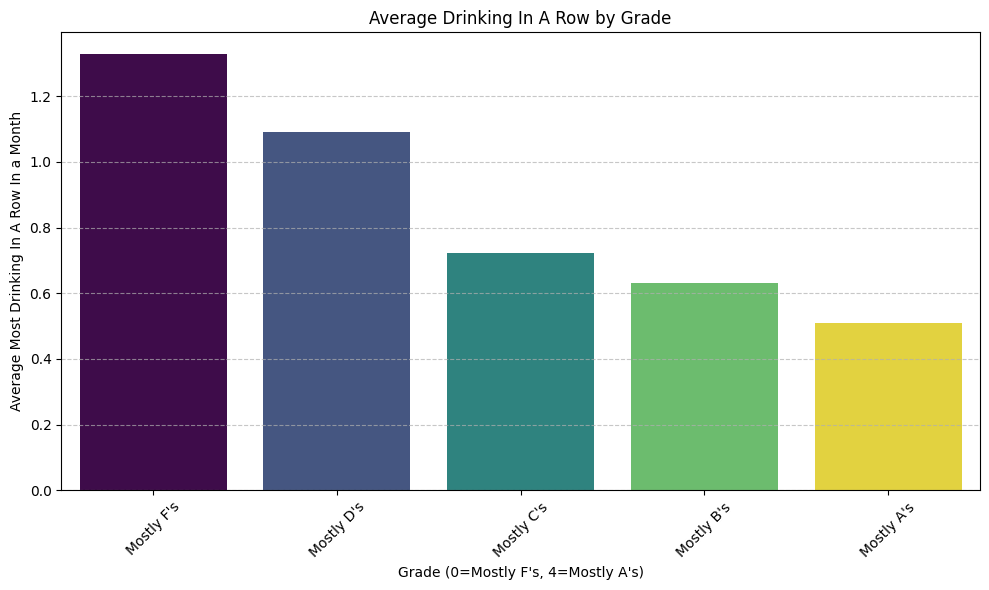

In [74]:
plt.figure(figsize=(10, 6))
sns.barplot(x=grade_alcohol_means.index, y='drinking_in_a_row', data=grade_alcohol_means, palette='viridis', hue=grade_alcohol_means.index, legend=False)
plt.title('Average Drinking In A Row by Grade')
plt.xlabel('Grade (0=Mostly F\'s, 4=Mostly A\'s)')
plt.ylabel('Average Most Drinking In A Row In a Month')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Mostly F\'s', 'Mostly D\'s', 'Mostly C\'s', 'Mostly B\'s', 'Mostly A\'s'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

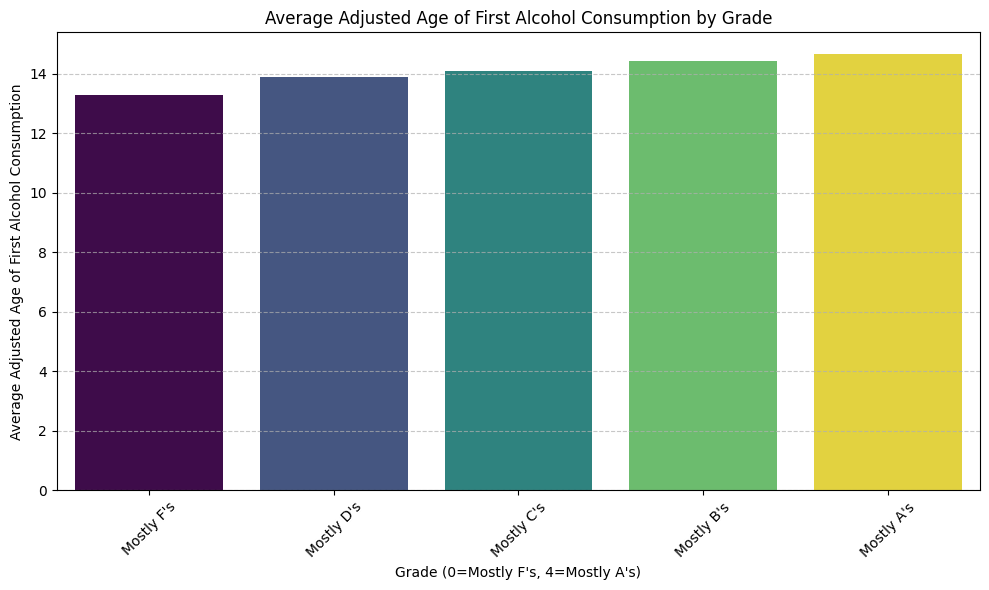

In [60]:
# Make a copy of cleaned_data to perform the requested modification without altering the original DataFrame
df_for_plot = cleaned_data.copy()

# Change the value of 'first_alcohol' to 'age' if 'first_alcohol' is 0
df_for_plot.loc[df_for_plot['first_alcohol'] == 0, 'first_alcohol'] = df_for_plot['age']

# Now, group by 'grade' and calculate the mean of the *modified 'first_alcohol'* column
avg_first_alcohol_by_grade = df_for_plot.groupby('grade')['first_alcohol'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='grade', y='first_alcohol', data=avg_first_alcohol_by_grade, palette='viridis', hue='grade', legend=False)
plt.title('Average Adjusted Age of First Alcohol Consumption by Grade')
plt.xlabel('Grade (0=Mostly F\'s, 4=Mostly A\'s)')
plt.ylabel('Average Adjusted Age of First Alcohol Consumption')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Mostly F\'s', 'Mostly D\'s', 'Mostly C\'s', 'Mostly B\'s', 'Mostly A\'s'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [65]:
personal_related_data = cleaned_data[['grade','exercise', 'social_media', 'mental_health', 'hours_of_sleep','sleep_place','have_friend']]
personal_related_data.head(20)

,grade,exercise,social_media,mental_health,hours_of_sleep,sleep_place,have_friend
1,1.0,4.0,3.0,2.0,8.0,Home of parent or gaurdian,3.0
2,2.0,7.0,7.0,1.0,4.0,Home of parent or gaurdian,3.0
3,2.0,2.0,7.0,2.0,7.0,Home of parent or gaurdian,1.0
4,1.0,7.0,5.0,2.0,6.0,Home of parent or gaurdian,3.0
5,0.0,5.0,7.0,2.0,5.0,Home of parent or gaurdian,4.0
6,2.0,7.0,7.0,2.0,5.0,Somewhere else,2.0
8,1.0,0.0,5.0,2.0,4.0,Home of parent or gaurdian,1.0
10,4.0,0.0,0.0,0.0,10.0,Home of parent or gaurdian,3.0
11,3.0,4.0,5.0,0.0,7.0,Home of parent or gaurdian,2.0
13,2.0,0.0,5.0,0.0,5.0,Home of parent or gaurdian,1.0


In [69]:
grade_personal_means = personal_related_data.groupby('grade').mean(numeric_only=True)
display(grade_personal_means)

,exercise,social_media,mental_health,hours_of_sleep,have_friend
grade,,,,,
0.0,2.970356,5.458498,2.266798,5.839921,2.416996
1.0,3.486936,5.174584,2.112827,6.033254,2.391924
2.0,3.752156,5.205474,1.904762,6.320960,2.509186
3.0,4.119160,5.155870,1.822144,6.568316,2.592069
4.0,4.232802,4.967654,1.838421,6.739560,2.716325


<Figure size 1400x800 with 0 Axes>

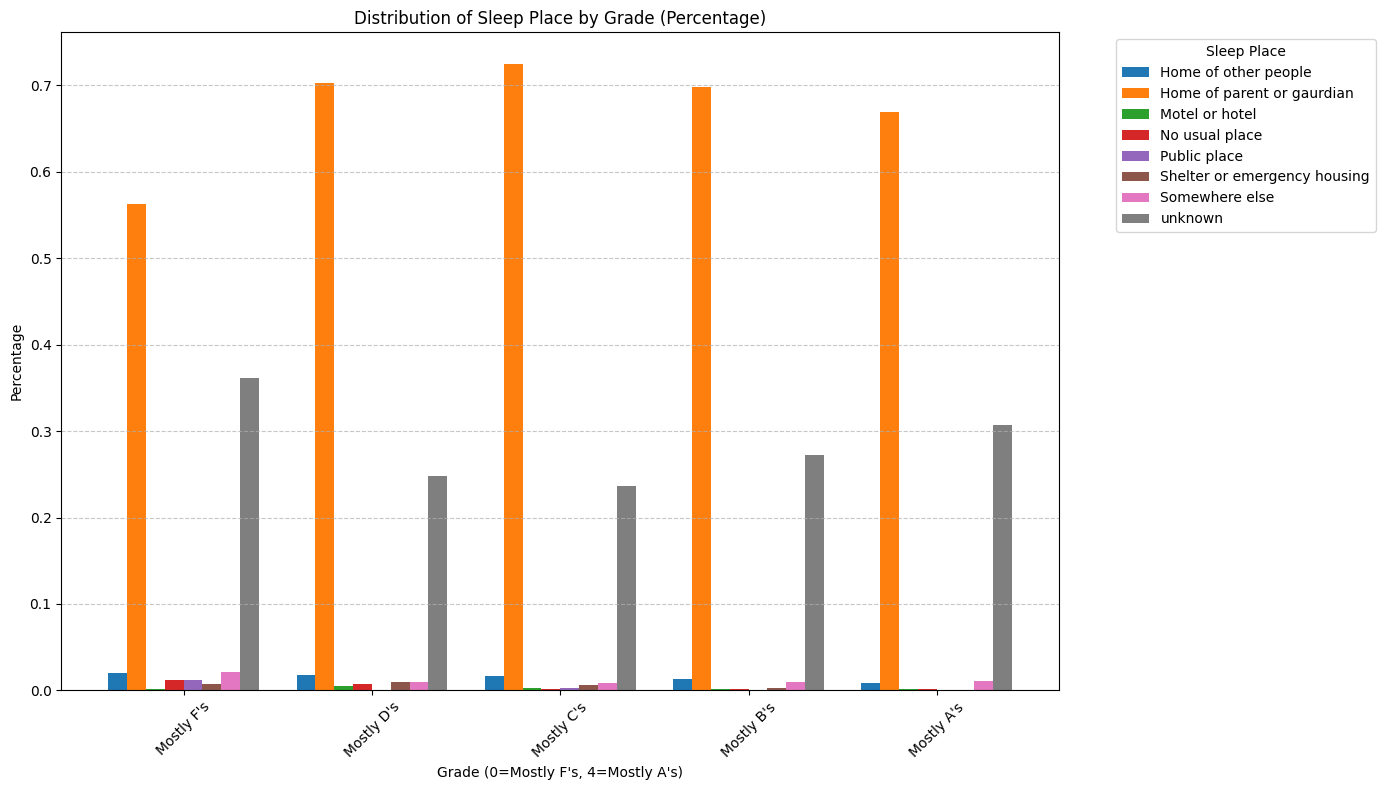

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation of 'grade' and 'sleep_place'
sleep_grade_crosstab = pd.crosstab(cleaned_data['grade'], cleaned_data['sleep_place'])

# Normalize the crosstab to get percentages for each grade
sleep_grade_percentage = sleep_grade_crosstab.div(sleep_grade_crosstab.sum(1).astype(float), axis=0)

# Plotting the multi-bar chart
plt.figure(figsize=(14, 8)) # Increased figure size for better readability
sleep_grade_percentage.plot(kind='bar', figsize=(14, 8), width=0.8) # Removed stacked=True and adjusted width

plt.title('Distribution of Sleep Place by Grade (Percentage)')
plt.xlabel('Grade (0=Mostly F\'s, 4=Mostly A\'s)')
plt.ylabel('Percentage')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Mostly F\'s', 'Mostly D\'s', 'Mostly C\'s', 'Mostly B\'s', 'Mostly A\'s'], rotation=45)
plt.legend(title='Sleep Place', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

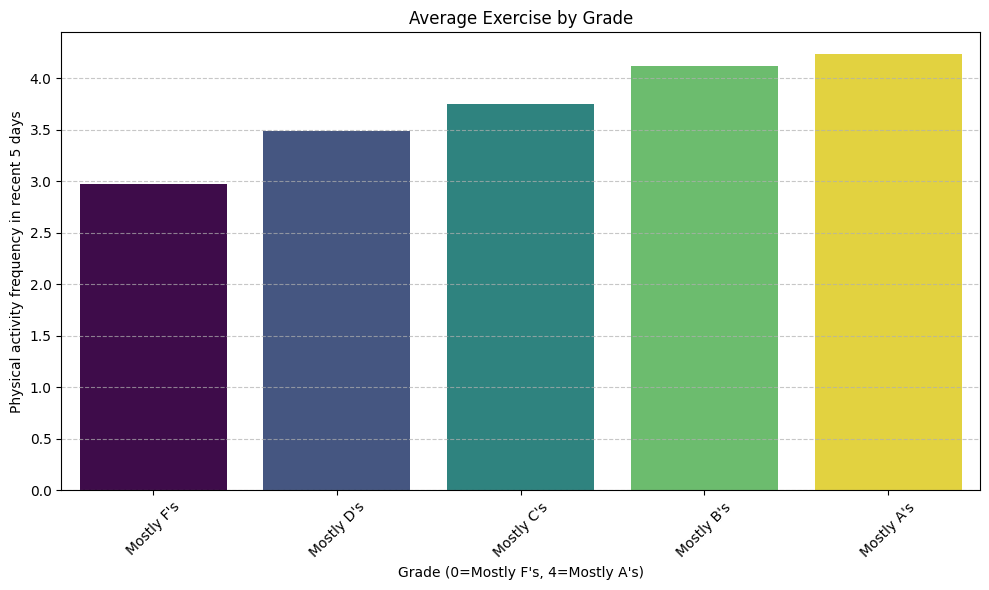

In [75]:
plt.figure(figsize=(10, 6))
sns.barplot(x=grade_alcohol_means.index, y='exercise', data=grade_personal_means, palette='viridis', hue=grade_alcohol_means.index, legend=False)
plt.title('Average Exercise by Grade')
plt.xlabel('Grade (0=Mostly F\'s, 4=Mostly A\'s)')
plt.ylabel('Physical activity frequency in recent 5 days')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Mostly F\'s', 'Mostly D\'s', 'Mostly C\'s', 'Mostly B\'s', 'Mostly A\'s'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

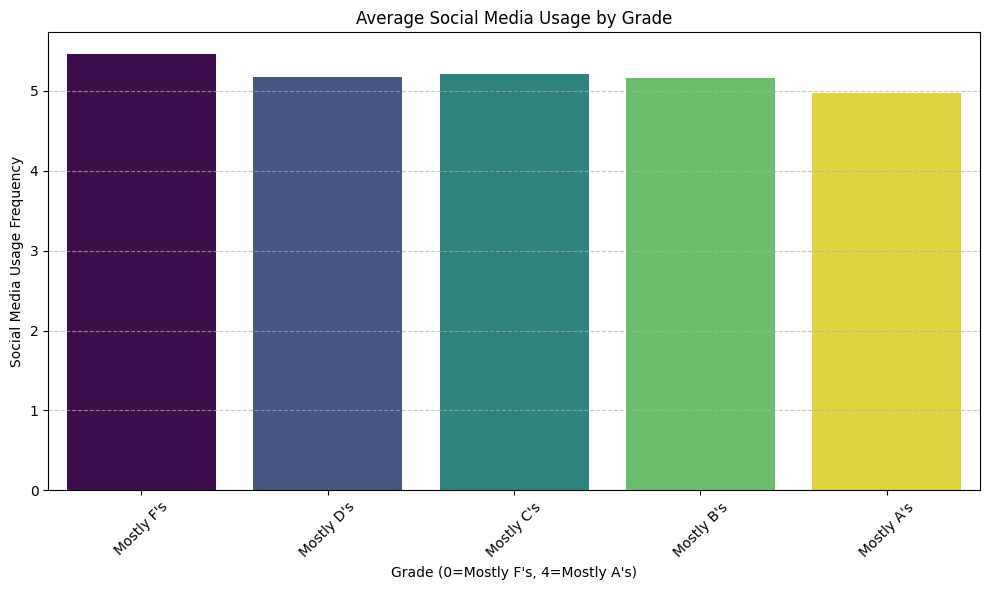

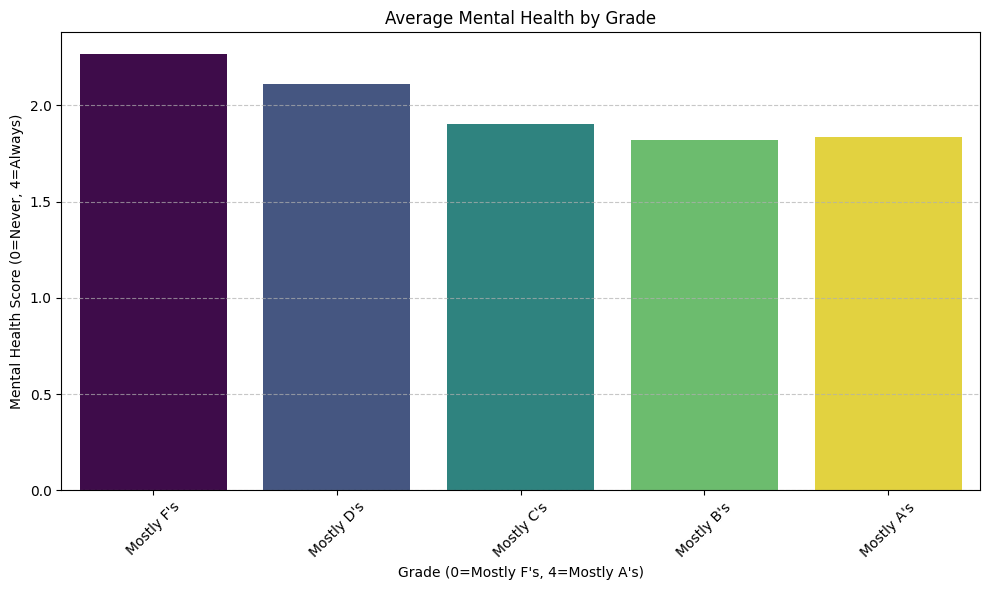

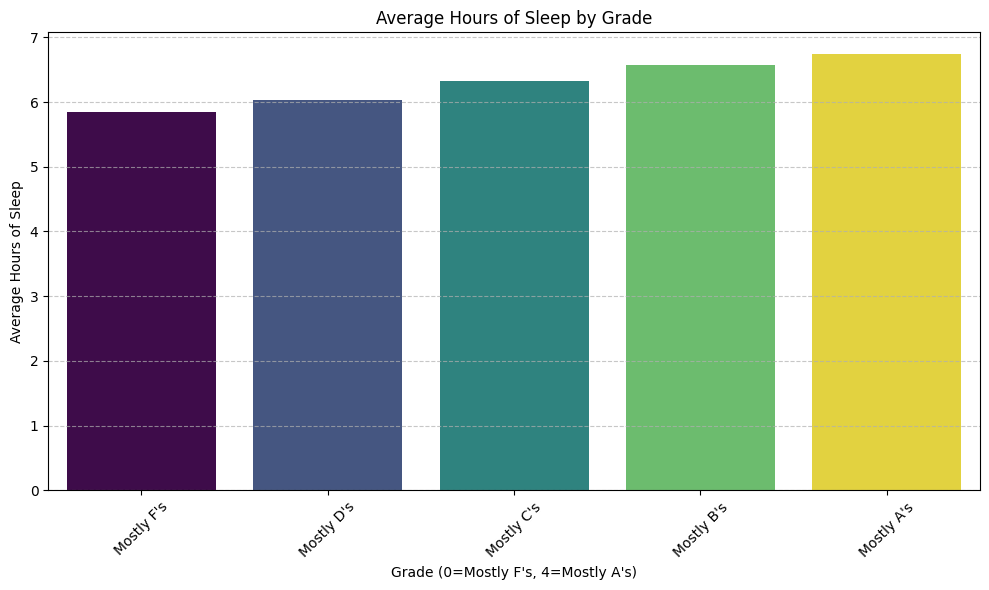

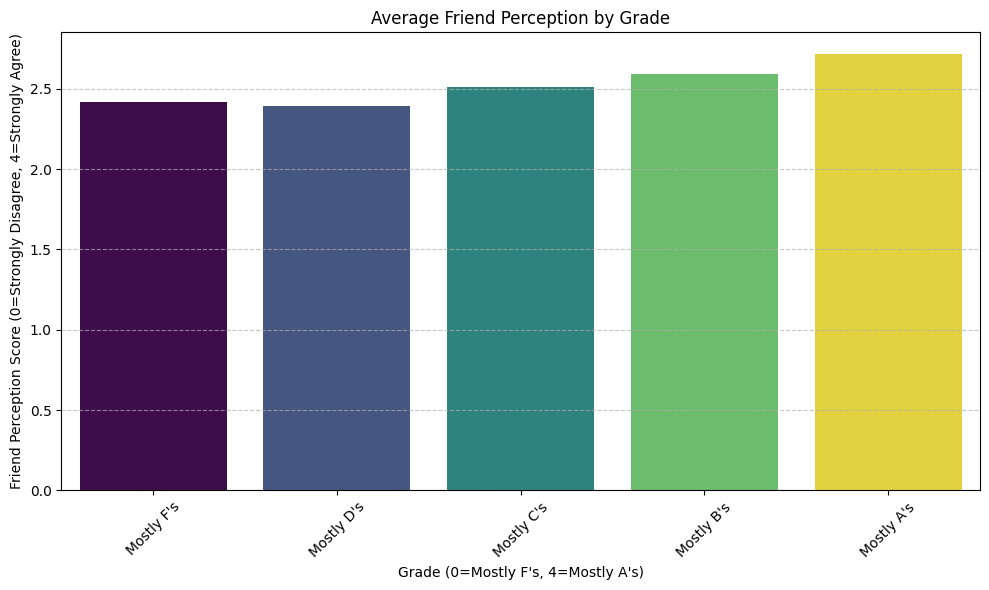

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

variables_to_plot = [
    {'column': 'social_media', 'title': 'Average Social Media Usage by Grade', 'ylabel': 'Social Media Usage Frequency'},
    {'column': 'mental_health', 'title': 'Average Mental Health by Grade', 'ylabel': 'Mental Health Score (0=Never, 4=Always)'},
    {'column': 'hours_of_sleep', 'title': 'Average Hours of Sleep by Grade', 'ylabel': 'Average Hours of Sleep'},
    {'column': 'have_friend', 'title': 'Average Friend Perception by Grade', 'ylabel': 'Friend Perception Score (0=Strongly Disagree, 4=Strongly Agree)'}
]

for var_info in variables_to_plot:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=grade_personal_means.index, y=var_info['column'], data=grade_personal_means, palette='viridis', hue=grade_personal_means.index, legend=False)
    plt.title(var_info['title'])
    plt.xlabel('Grade (0=Mostly F\'s, 4=Mostly A\'s)')
    plt.ylabel(var_info['ylabel'])
    plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Mostly F\'s', 'Mostly D\'s', 'Mostly C\'s', 'Mostly B\'s', 'Mostly A\'s'], rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()